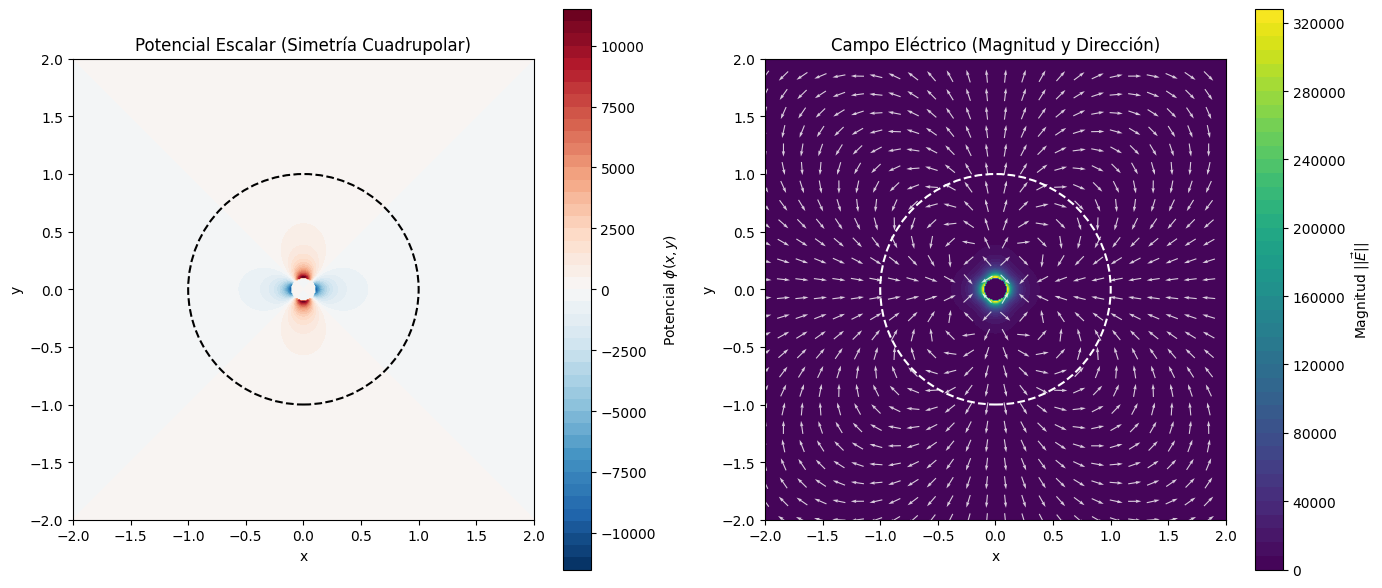

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARÁMETROS ADIMENSIONALES DEL PROBLEMA
# ==========================================
R = 1.0
alpha = 1.0
rho0 = 1.0
eps0 = 1.0

resolucion = 400
res_flechas = 25

limite = 2.0 * R
x_lineal = np.linspace(-limite, limite, resolucion)
y_lineal = np.linspace(-limite, limite, resolucion)
X, Y = np.meshgrid(x_lineal, y_lineal)

r = np.sqrt(X**2 + Y**2)
r = np.where(r == 0, 1e-10, r)
phi = np.arctan2(Y, X)

# ==========================================
# 2. FUNCIONES ROBUSTAS (Evitan singularidad en el centro)
# ==========================================
def eval_I1_r3(r_val, R_val, a_val):
    res = np.zeros_like(r_val)
    mask = r_val < 0.1

    # Taylor para el centro (evita cancelación catastrófica)
    rs = r_val[mask]
    x = a_val * rs / R_val
    res[mask] = rs**3 * (1/6 + x/7 + x**2/16 + x**3/54 + x**4/240)

    # Fórmula exacta para el resto
    rg = r_val[~mask]
    I1_g = np.exp(a_val*rg/R_val) * ( (R_val*rg**5)/a_val - (5*R_val**2*rg**4)/a_val**2 +
                                   (20*R_val**3*rg**3)/a_val**3 - (60*R_val**4*rg**2)/a_val**4 +
                                   (120*R_val**5*rg)/a_val**5 - (720*R_val**6)/a_val**6 ) + (720*R_val**6)/a_val**6
    res[~mask] = I1_g / rg**3
    return res

def eval_I1_r4(r_val, R_val, a_val):
    res = np.zeros_like(r_val)
    mask = r_val < 0.1

    rs = r_val[mask]
    x = a_val * rs / R_val
    res[mask] = rs**2 * (1/6 + x/7 + x**2/16 + x**3/54 + x**4/240)

    rg = r_val[~mask]
    I1_g = np.exp(a_val*rg/R_val) * ( (R_val*rg**5)/a_val - (5*R_val**2*rg**4)/a_val**2 +
                                   (20*R_val**3*rg**3)/a_val**3 - (60*R_val**4*rg**2)/a_val**4 +
                                   (120*R_val**5*rg)/a_val**5 - (720*R_val**6)/a_val**6 ) + (720*R_val**6)/a_val**6
    res[~mask] = I1_g / rg**4
    return res

# ==========================================
# 3. CÁLCULO DE LAS FUNCIONES RADIALES
# ==========================================
I2 = (R/alpha) * (np.exp(alpha) - np.exp(alpha*r/R))

Term_I1_r3 = eval_I1_r3(r, R, alpha)
Term_I1_r4 = eval_I1_r4(r, R, alpha)

f_r = (rho0 / (5 * eps0 * R)) * (Term_I1_r3 + r**2 * I2)
df_r = (rho0 / (5 * eps0 * R)) * (-3 * Term_I1_r4 + 2 * r * I2)

# Región Interior
phi_int = f_r * np.cos(2 * phi)
Er_int = -df_r * np.cos(2 * phi)
Ephi_int = (2 * f_r / r) * np.sin(2 * phi)

# Región Exterior
Q = (rho0 * R**5 / (5 * eps0 * alpha**6)) * (np.exp(alpha) * (alpha**5 - 5*alpha**4 + 20*alpha**3 - 60*alpha**2 + 120*alpha - 720) + 720)
phi_ext = (Q / r**3) * np.cos(2 * phi)
Er_ext = (3 * Q / r**4) * np.cos(2 * phi)
Ephi_ext = (2 * Q / r**4) * np.sin(2 * phi)

# ==========================================
# 4. MATRICES GLOBALES Y ROTACIÓN
# ==========================================
mask_interior = r <= R

Phi_total = np.where(mask_interior, phi_int, phi_ext)
Er_total = np.where(mask_interior, Er_int, Er_ext)
Ephi_total = np.where(mask_interior, Ephi_int, Ephi_ext)

Ex = Er_total * np.cos(phi) - Ephi_total * np.sin(phi)
Ey = Er_total * np.sin(phi) + Ephi_total * np.cos(phi)
E_mag = np.sqrt(Ex**2 + Ey**2)

# ==========================================
# 5. VISUALIZACIÓN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cmap1 = ax1.contourf(X, Y, Phi_total, levels=50, cmap='RdBu_r')
fig.colorbar(cmap1, ax=ax1, label='Potencial $\\phi(x,y)$')
circulo1 = plt.Circle((0, 0), R, color='black', fill=False, linestyle='--', linewidth=1.5)
ax1.add_patch(circulo1)
ax1.set_aspect('equal')
ax1.set_title('Potencial Escalar (Simetría Cuadrupolar)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

cmap2 = ax2.contourf(X, Y, E_mag, levels=50, cmap='viridis')
fig.colorbar(cmap2, ax=ax2, label='Magnitud $||\\vec{E}||$')
circulo2 = plt.Circle((0, 0), R, color='white', fill=False, linestyle='--', linewidth=1.5)
ax2.add_patch(circulo2)

salto = resolucion // res_flechas
X_q, Y_q = X[::salto, ::salto], Y[::salto, ::salto]
Ex_q, Ey_q = Ex[::salto, ::salto], Ey[::salto, ::salto]
E_mag_q = np.sqrt(Ex_q**2 + Ey_q**2)

# Normalizar flechas para ver bien la dirección sin abrumar la gráfica
ax2.quiver(X_q, Y_q, Ex_q/E_mag_q, Ey_q/E_mag_q, color='white', pivot='mid', scale=35, alpha=0.8)

ax2.set_aspect('equal')
ax2.set_title('Campo Eléctrico (Magnitud y Dirección)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()